# 05. Flower Classification using VGG16 model

The project utilizes a dataset containing images of various flower species. The dataset is divided into a training set and a test set, each labeled with the corresponding flower species. There are 102 flower species.

In [1]:
# Import libraries
from pathlib import Path
import matplotlib.pyplot as plt
import torch
import torchvision.models
from torch import nn
from torchinfo import summary
from torchvision import datasets
from torchvision import transforms
from torchvision.models import ResNet152_Weights

from src.data_loader import create_dataloaders
from src.models.vgg_16 import VGG16
from src.utils import set_device_agnostic_mode
from src.training import train_model

/opt/anaconda3/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'dlopen(/opt/anaconda3/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <CFED5F8E-EC3F-36FD-AAA3-2C6C7F8D3DD9> /opt/anaconda3/lib/python3.11/site-packages/torchvision/image.so
  Expected in:     <CDAC6E34-8608-3E70-8B2F-32BCD38E90FB> /opt/anaconda3/lib/python3.11/site-packages/torch/lib/libtorch_cpu.dylib'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
# Initialize training parameters and get device
train_dir = 'data/train'
val_dir = 'data/val'

# Get a device to use for training/inference
device = set_device_agnostic_mode()

In [3]:
# Create VGG16 CNN model

# VGG16 params and transforms
COLOR_CHANNELS = 3
BATCH_SIZE = 32
EPOCHS = 50

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.1),
    transforms.RandomAffine(degrees=40, translate=None, scale=(1, 2), shear=15),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

# Create training and validation data loaders
train_dataloader, val_dataloader, classes = create_dataloaders(train_dir, val_dir, train_transform, 
                                                               val_transform, BATCH_SIZE)

In [4]:
# Download model from here and save it to the models directory (Since Github doesn't store large files)
# Download link: https://drive.google.com/file/d/1o-rckSP98r_tM_r3rV5DO6BqC70vLklF/view?usp=sharing

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


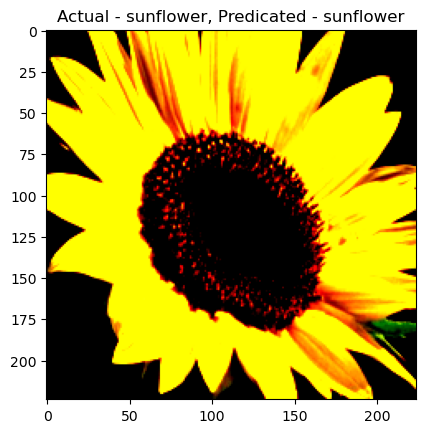

In [6]:
# Load and predict using VGG16 model
MODEL_PATH = Path("models")
MODEL_NAME = "05_flower_classification_vgg16.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

loaded_model =  VGG16(COLOR_CHANNELS, len(classes))
loaded_model.load_state_dict(torch.load(MODEL_SAVE_PATH))
loaded_model.to(device)

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

test_dataset = datasets.Flowers102(
    root=val_dir,
    split='val',
    transform=test_transforms
)

random_index = torch.randint(0, len(test_dataset), (1,)).item()
image, label = test_dataset[random_index]
image = image.to(device)

loaded_model.eval()
with torch.inference_mode():
    y_logits = loaded_model(image.unsqueeze(dim=0))
    predicted_label = torch.argmax(y_logits, dim=1)
    
plt.title(f'Actual - {classes[label]}, Predicated - {classes[predicted_label.item()]}')
plt.imshow(image.cpu().permute(1, 2, 0))